# ADIM 2 — Modelleme tabanı + Olasılık kalibrasyonu

5 **etiketli** churn seti (telco, cell2cell, bank, ecommerce, iranian) **bağımsız**
işlenir; asla birleştirilmez. cell2cell etiketsiz holdout bu adıma girmez.

Amaç: her set için **dürüst bir temel performans** + **iyi kalibre olasılık**
(Adım 5 kâr/ROI'nin önkoşulu). **Dengeleme/resampling YOK, class_weight YOK** —
doğal dağılımda baseline (azınlık-sınıf sorunu PR-AUC/recall'da görünsün, RQ1'i
motive etsin). Encoding sızıntısız (yalnız train-fold'da fit). Birincil skor PR-AUC.
Ağır mantık `src/` fonksiyonlarındadır.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml bulunamadı — depo kökünden çalıştırın")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import config as cfg
from src import evaluate as ev
from src import models as models_mod
from src import plotstyle as ps
from src import strings_tr as S

np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Veri yükleme
Girdi: `data/processed/<set>_clean.csv` (5 etiketli set). Her set ayrı tutulur.

In [2]:
veriler = {}
for key in cfg.DATASETS:
    veriler[key] = pd.read_csv(cfg.PROCESSED / f"{key}_clean.csv")
    yaz(f"{key:11s} {veriler[key].shape}  churn=%{100*veriler[key]['churn'].mean():.1f}")

telco       (7043, 20)  churn=%26.5
cell2cell   (51047, 57)  churn=%28.8
ecommerce   (3941, 11)  churn=%17.1
iranian     (3150, 14)  churn=%15.7
bank        (10000, 11)  churn=%20.4


## 2. Modelleme + kalibrasyon (HPO + 5-kat CV)
Her set için 4 model (LogReg, RF, XGBoost, LightGBM). XGB/LGBM ~40 trial
RandomizedSearchCV (PR-AUC), RF hafif, LogReg C taraması. Her model için HEM
Platt HEM Isotonic kalibrasyon, fold içinde. **(En uzun adım.)**

In [3]:
yaz(S.MSG["bolum"].format(ad="MODELLEME + KALİBRASYON"))
tum = {}
for key in cfg.DATASETS:
    t = time.time()
    tum[key] = ev.calistir_set(key, veriler[key], cfg.SEED)
    for m, res in tum[key]["sonuc"].items():
        yaz(S.MSG2["hpo"].format(set=key, model=S.MODEL_AD[m], skor=res["hpo_skor"]))
    yaz(f"  -> {key} bitti ({time.time()-t:.0f}s)")

===== MODELLEME + KALİBRASYON =====


telco / Logistic Regression: HPO bitti (en iyi PR-AUC=0.6569)
telco / Random Forest: HPO bitti (en iyi PR-AUC=0.6627)
telco / XGBoost: HPO bitti (en iyi PR-AUC=0.6648)
telco / LightGBM: HPO bitti (en iyi PR-AUC=0.6635)
  -> telco bitti (54s)


cell2cell / Logistic Regression: HPO bitti (en iyi PR-AUC=0.3840)
cell2cell / Random Forest: HPO bitti (en iyi PR-AUC=0.4507)
cell2cell / XGBoost: HPO bitti (en iyi PR-AUC=0.4664)
cell2cell / LightGBM: HPO bitti (en iyi PR-AUC=0.4661)
  -> cell2cell bitti (1967s)


ecommerce / Logistic Regression: HPO bitti (en iyi PR-AUC=0.6841)
ecommerce / Random Forest: HPO bitti (en iyi PR-AUC=0.8911)
ecommerce / XGBoost: HPO bitti (en iyi PR-AUC=0.8898)
ecommerce / LightGBM: HPO bitti (en iyi PR-AUC=0.9075)
  -> ecommerce bitti (38s)


iranian / Logistic Regression: HPO bitti (en iyi PR-AUC=0.7628)
iranian / Random Forest: HPO bitti (en iyi PR-AUC=0.9349)
iranian / XGBoost: HPO bitti (en iyi PR-AUC=0.9522)
iranian / LightGBM: HPO bitti (en iyi PR-AUC=0.9576)
  -> iranian bitti (30s)


bank / Logistic Regression: HPO bitti (en iyi PR-AUC=0.4717)
bank / Random Forest: HPO bitti (en iyi PR-AUC=0.7013)
bank / XGBoost: HPO bitti (en iyi PR-AUC=0.7100)
bank / LightGBM: HPO bitti (en iyi PR-AUC=0.7065)
  -> bank bitti (93s)


## 3. Performans ve kalibrasyon tabloları
`model_performance.csv` (PR-AUC öne çıkar) ve `calibration_comparison.csv`
(ham / Platt / Isotonic; Brier + ECE). Değerler fold-ortalaması ± std.

In [4]:
perf = ev.tablo_performans(tum)
kal = ev.tablo_kalibrasyon(tum)
yaz(S.MSG["bolum"].format(ad="MODEL PERFORMANSI (fold ort. ± std)"))
yaz(perf.to_string(index=False))
yaz(S.MSG["bolum"].format(ad="KALİBRASYON KIYASI"))
yaz(kal.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "model_performance.csv"))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "calibration_comparison.csv"))

===== MODEL PERFORMANSI (fold ort. ± std) =====
Veri Seti               Model          PR-AUC         ROC-AUC      Duyarlılık        Kesinlik              F1
    telco Logistic Regression 0.6569 ± 0.0261 0.8452 ± 0.0133 0.5527 ± 0.0305 0.6588 ± 0.0203 0.6010 ± 0.0262
    telco       Random Forest 0.6627 ± 0.0269 0.8472 ± 0.0114 0.5099 ± 0.0267 0.6676 ± 0.0174 0.5780 ± 0.0224
    telco             XGBoost 0.6648 ± 0.0239 0.8473 ± 0.0118 0.5254 ± 0.0216 0.6643 ± 0.0154 0.5866 ± 0.0184
    telco            LightGBM 0.6635 ± 0.0223 0.8469 ± 0.0108 0.5179 ± 0.0353 0.6661 ± 0.0241 0.5825 ± 0.0303
cell2cell Logistic Regression 0.3840 ± 0.0063 0.6204 ± 0.0049 0.0311 ± 0.0013 0.4933 ± 0.0325 0.0584 ± 0.0024
cell2cell       Random Forest 0.4507 ± 0.0092 0.6741 ± 0.0063 0.0798 ± 0.0022 0.6262 ± 0.0368 0.1415 ± 0.0039
cell2cell             XGBoost 0.4664 ± 0.0071 0.6841 ± 0.0046 0.1355 ± 0.0049 0.6057 ± 0.0168 0.2215 ± 0.0068
cell2cell            LightGBM 0.4661 ± 0.0055 0.6843 ± 0.0037 0.1327 ± 0

## 4. Figürler
Her set için `outputs/figures/<set>/`: calibration_curves, pr_curve, roc_curve,
model_comparison (dpi=300, ortak stil, sabit churn/model renkleri, Türkçe etiket).

===== FİGÜRLER =====


telco: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/telco (kalibrasyon figürü: XGBoost)


cell2cell: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/cell2cell (kalibrasyon figürü: XGBoost)


ecommerce: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/ecommerce (kalibrasyon figürü: LightGBM)


iranian: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/iranian (kalibrasyon figürü: LightGBM)


bank: 4 figür -> /Users/emrahfidan/Desktop/churn-xai-profit/outputs/figures/bank (kalibrasyon figürü: XGBoost)


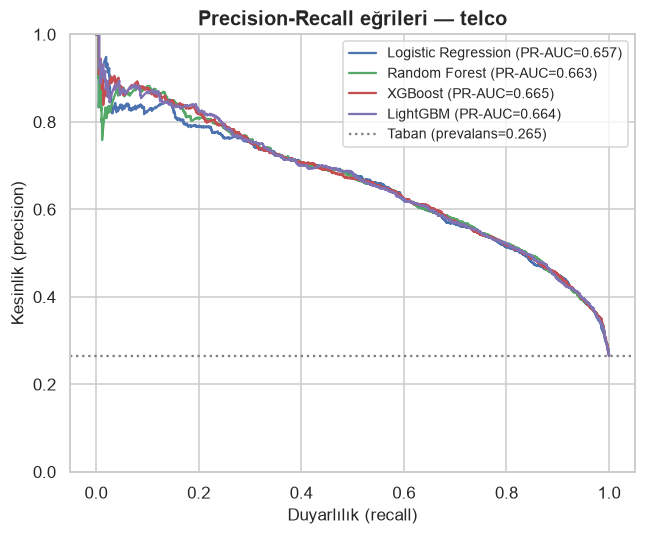

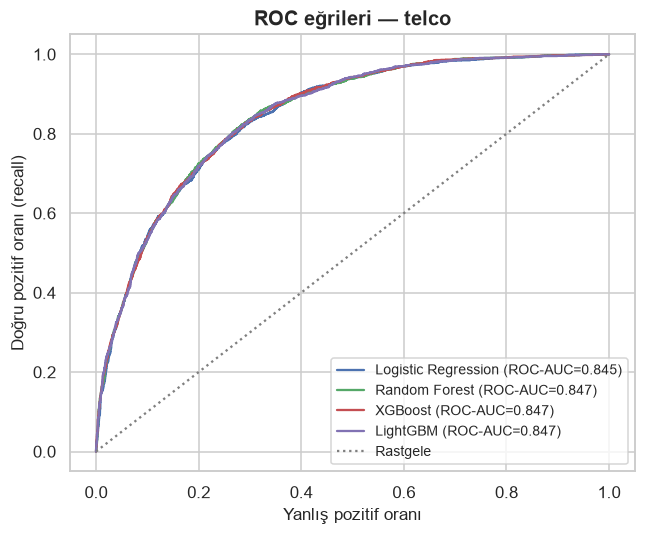

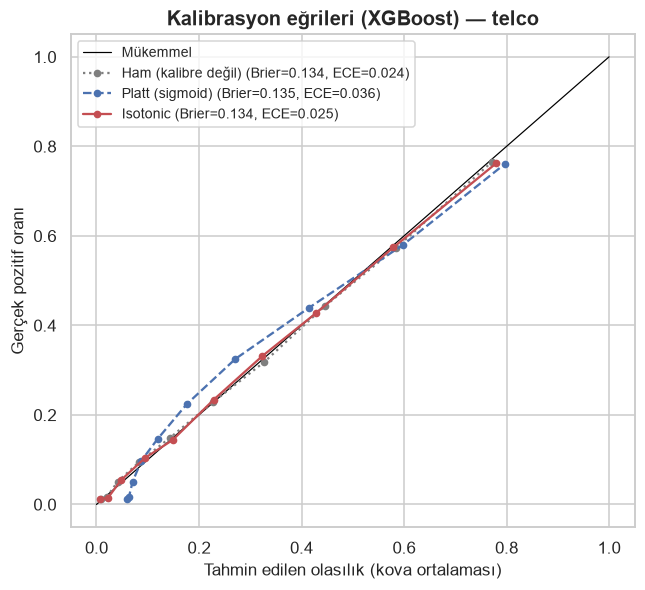

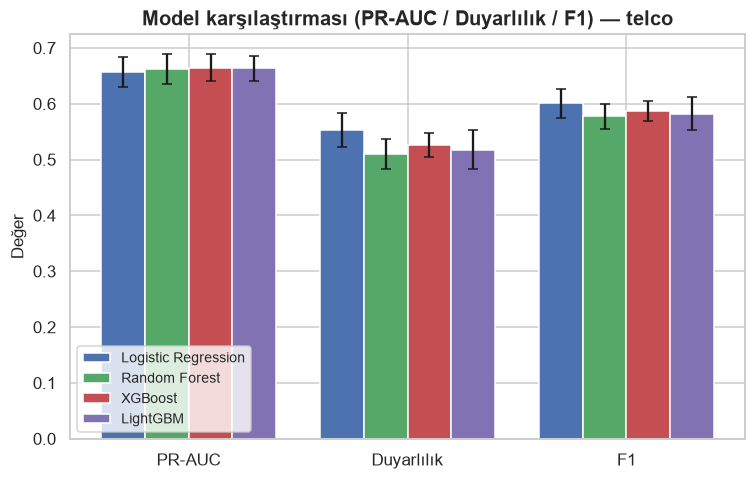

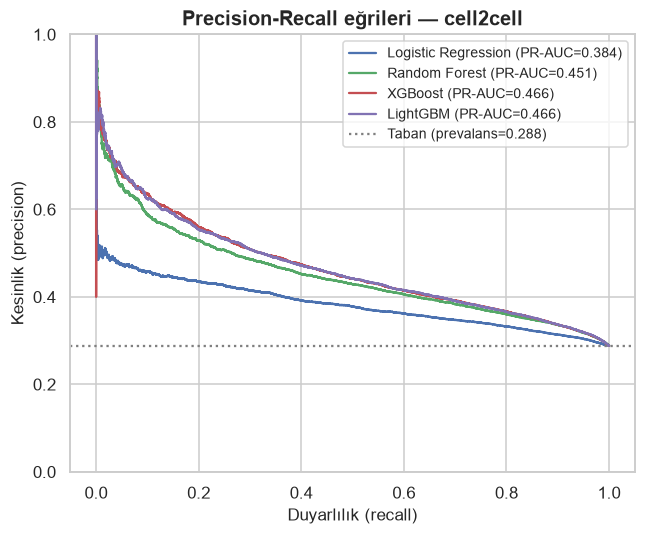

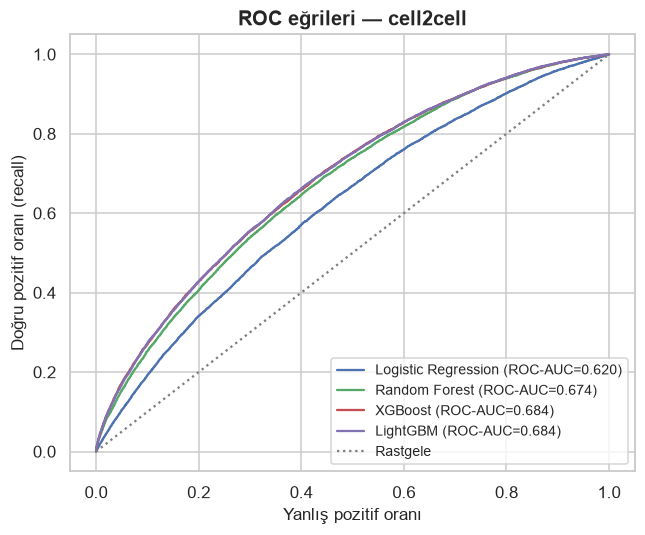

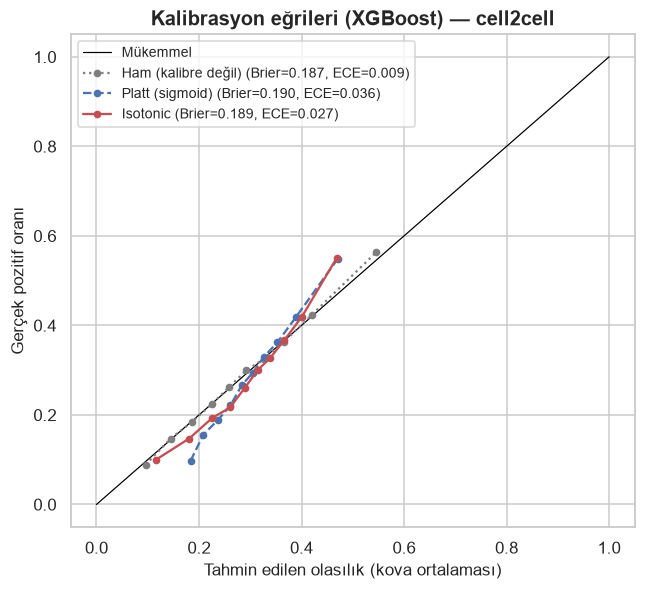

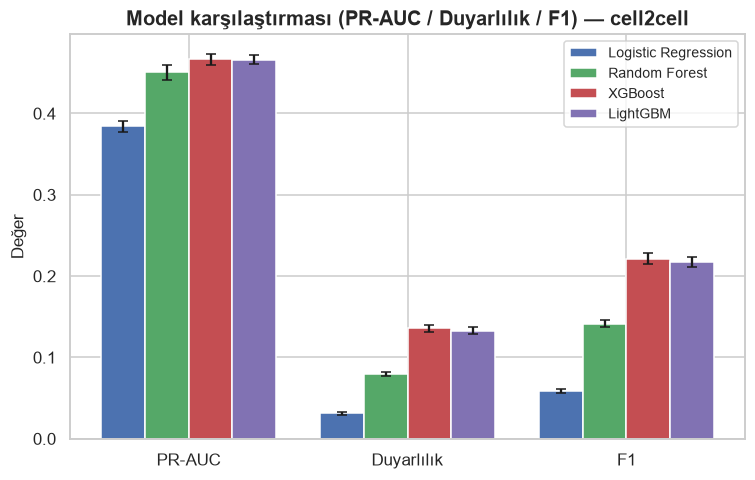

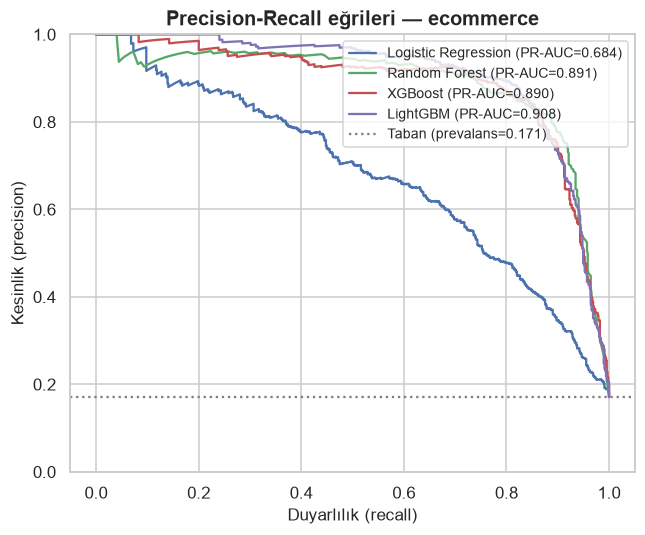

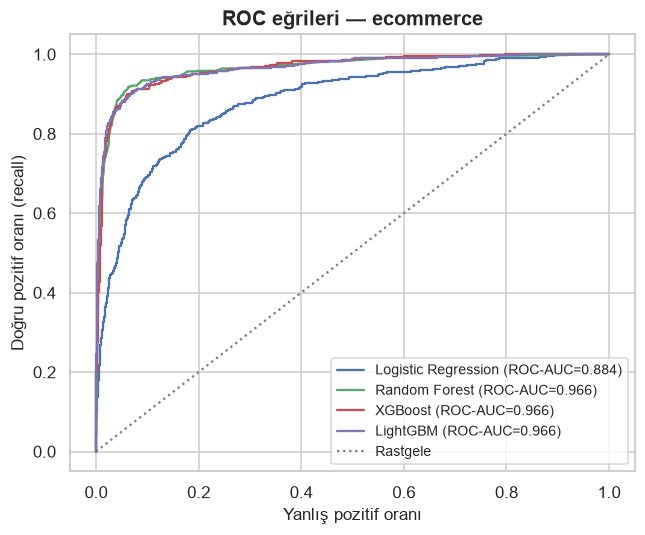

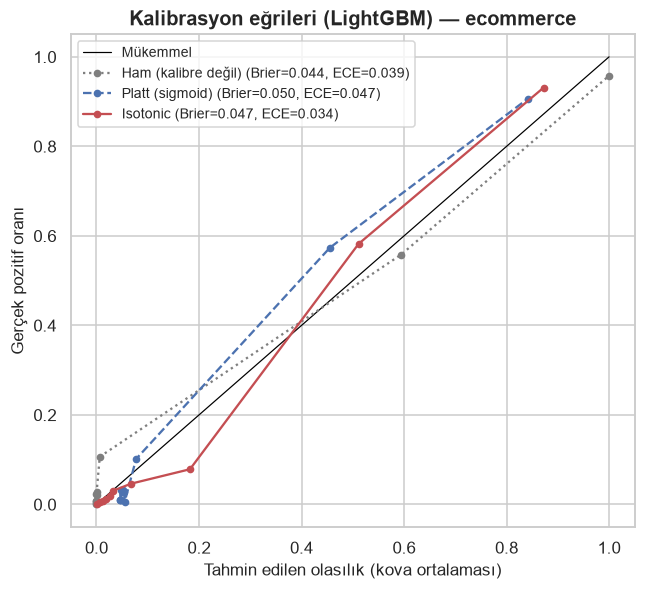

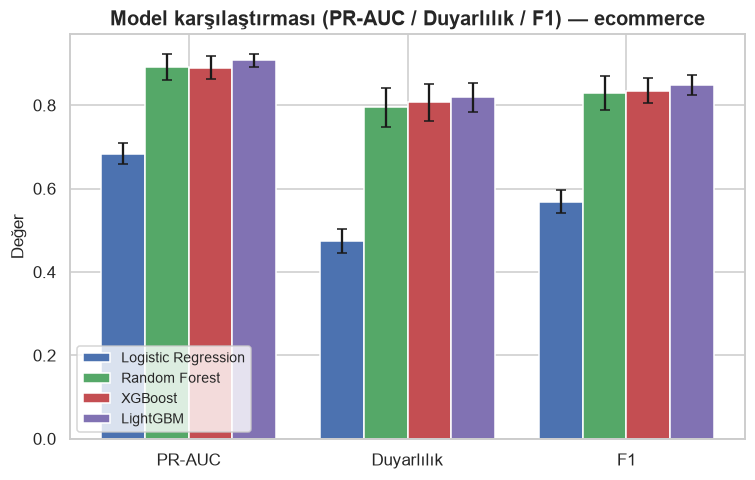

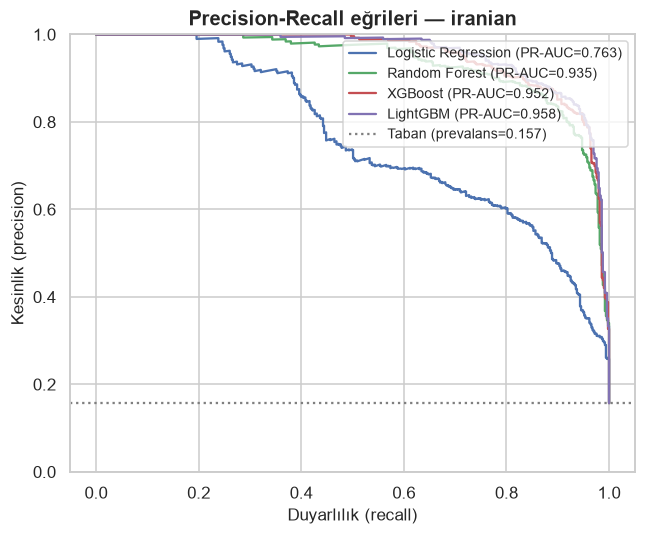

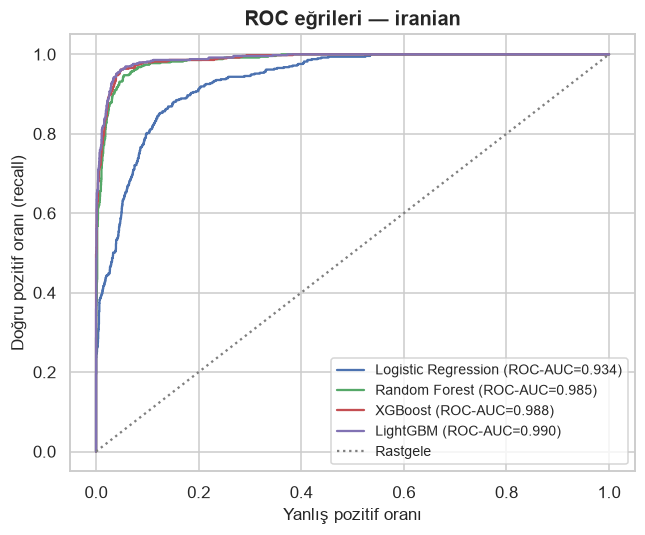

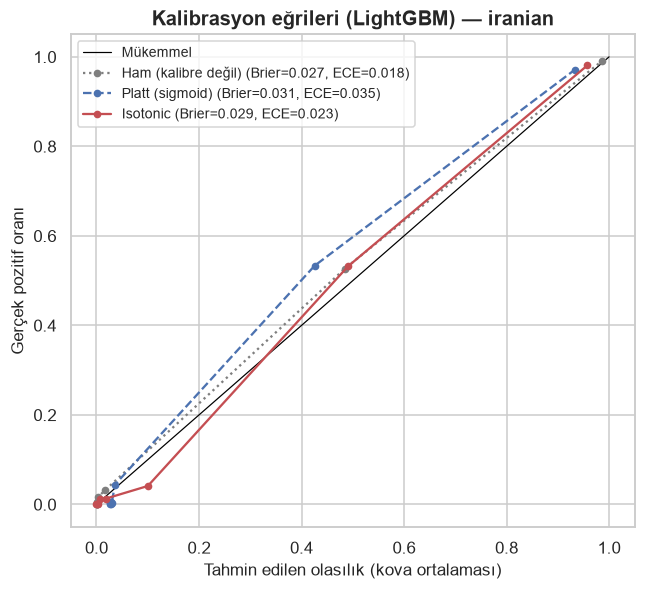

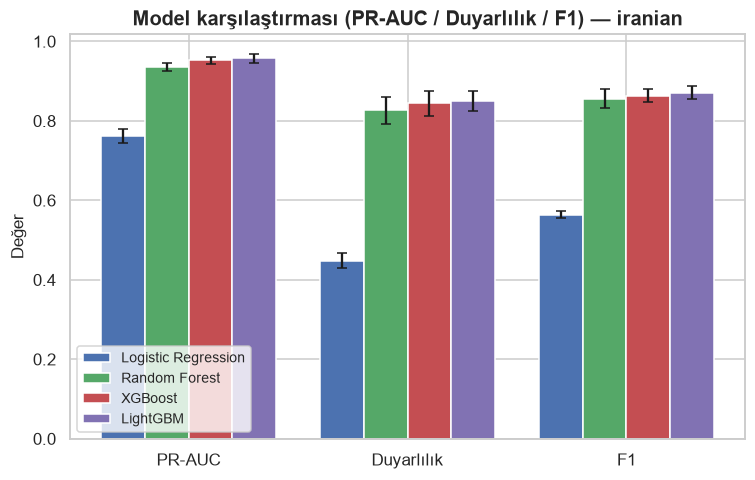

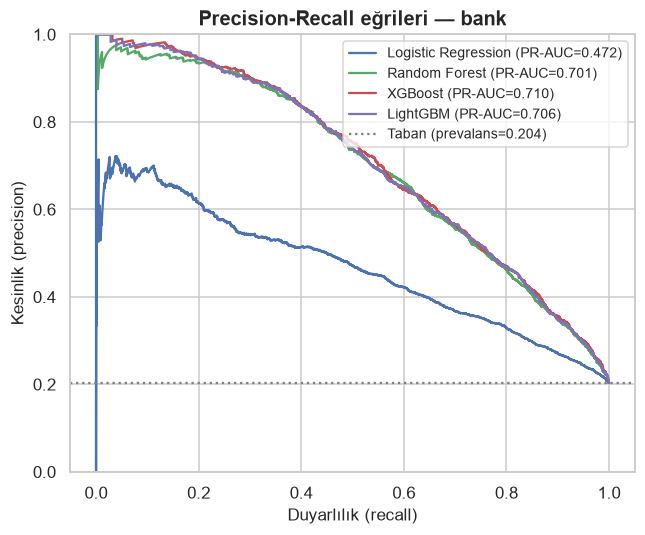

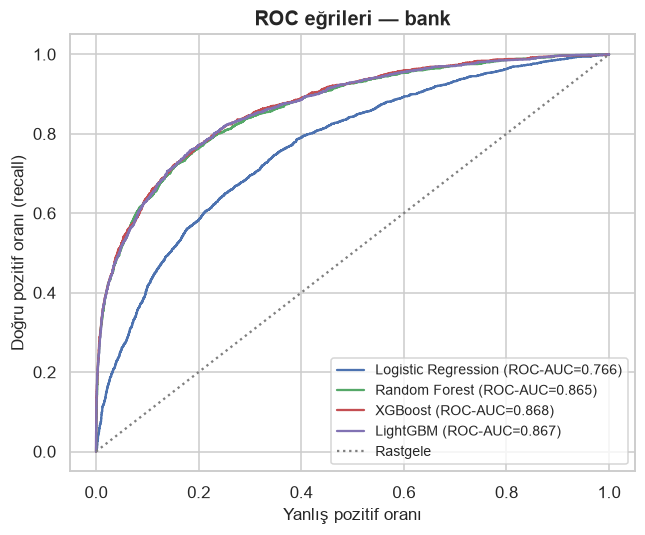

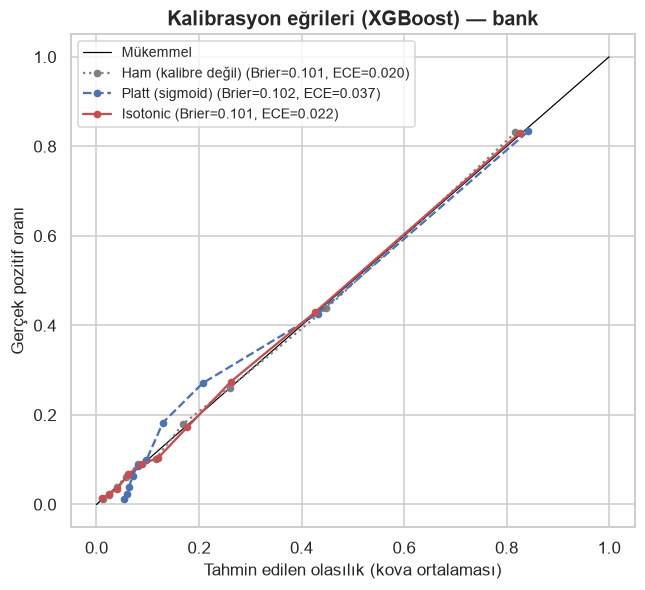

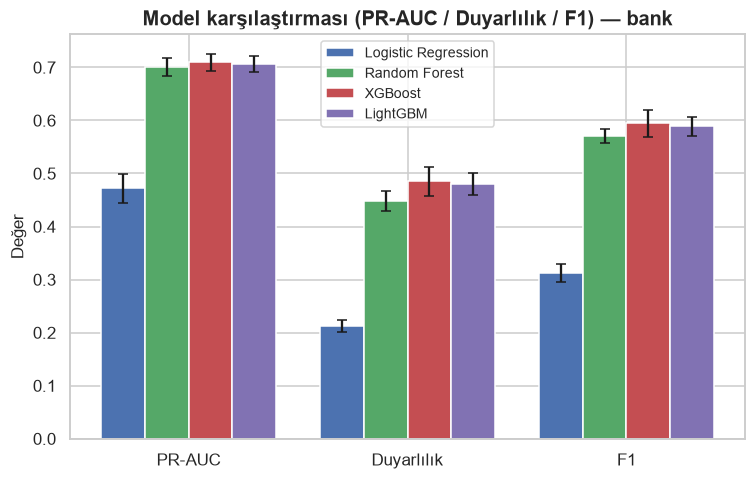

In [5]:
yaz(S.MSG["bolum"].format(ad="FİGÜRLER"))
en_iyiler = {}
for key in cfg.DATASETS:
    yollar, en_iyi = ev.figurler_set(key, tum[key], veriler[key]["churn"].to_numpy())
    en_iyiler[key] = en_iyi
    yaz(f"{key}: {len(yollar)} figür -> {cfg.FIGURES / key} (kalibrasyon figürü: {S.MODEL_AD[en_iyi]})")

## 5. iranian 'Status' baskınlığı
'Status' meşru bir prediktör (Adım 1). PR-AUC'yi tek başına mı taşıyor? Çıkarıp
bakıyoruz (LGBM, 5-kat PR-AUC).

In [6]:
full, drop = ev.iranian_status_etkisi(veriler["iranian"], cfg.SEED)
yaz(S.MSG["bolum"].format(ad="iranian 'Status' ETKİSİ"))
yaz(S.MSG2["iranian_status"].format(oncesi=f"{full:.4f}", sonrasi=f"{drop:.4f}",
                                    fark=drop - full, model="LightGBM"))

===== iranian 'Status' ETKİSİ =====
iranian: 'Status' çıkarılınca PR-AUC 0.9557 -> 0.9435 (fark -0.0122) [LightGBM]


## 6. Özet — kazananlar (karar kullanıcıda)
Set bazında en iyi model (PR-AUC) ve en iyi kalibrasyon (en düşük ECE). Seçimi
kullanıcı yapacak; burada yalnızca kanıt sunulur.

In [7]:
yaz(S.MSG["bolum"].format(ad="ÖZET — KAZANANLAR (karar kullanıcıda)"))
ozet_satir = []
for key in cfg.DATASETS:
    m = en_iyiler[key]
    res = tum[key]["sonuc"][m]
    pr = ev.pr_ortalama(res)
    kyon, eces = ev.en_iyi_kalibrasyon(res)
    ozet_satir.append({
        S.KOLON2["veri_seti"]: key,
        "En iyi model (PR-AUC)": f"{S.MODEL_AD[m]} ({pr:.3f})",
        "En iyi kalibrasyon (ECE)": f"{S.YONTEM_AD[kyon]} ({eces[kyon]:.3f})",
    })
ozet_df = pd.DataFrame(ozet_satir)
yaz(ozet_df.to_string(index=False))
yaz(S.MSG2["bitti"])

_log = cfg.LOGS / "adim2_ozet.log"
_log.write_text("\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== ÖZET — KAZANANLAR (karar kullanıcıda) =====
Veri Seti En iyi model (PR-AUC)    En iyi kalibrasyon (ECE)
    telco       XGBoost (0.665) Ham (kalibre değil) (0.024)
cell2cell       XGBoost (0.466) Ham (kalibre değil) (0.009)
ecommerce      LightGBM (0.908)            Isotonic (0.034)
  iranian      LightGBM (0.958) Ham (kalibre değil) (0.018)
     bank       XGBoost (0.710) Ham (kalibre değil) (0.020)
ADIM 2 tamamlandı. Model ailesi ve kalibrasyon seçimi kullanıcıya bırakıldı. Dengeleme (RQ1) yapılmadı.
Kaydedildi: /Users/emrahfidan/Desktop/churn-xai-profit/outputs/logs/adim2_ozet.log
